# Experiment 4

# Setup and Load Dataset

In [ ]:
import os, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

tf.keras.utils.set_random_seed(42)          # reproducibility

print("TF version :", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU        :", gpus if gpus else "NONE  <-- Runtime > Change runtime type > T4 GPU")

USE_MIXED_PRECISION = bool(gpus)
if USE_MIXED_PRECISION:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision:", tf.keras.mixed_precision.global_policy().name)
else:
    print("Mixed precision: disabled (no GPU detected)")

TF version : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision: mixed_float16


In [ ]:
# ------------------------- Configuration -------------------------
BASE_MODEL_NAME  = "vgg16"   # manual allows VGG16 / ResNet50 / MobileNetV2 / EfficientNetB0
IMG_SIZE         = 64        # CIFAR-10 is 32x32; ImageNet backbones need a larger input
BATCH_SIZE       = 32        # Task 3 spec
LEARNING_RATE    = 0.001     # Task 3 spec
EPOCHS_HEAD      = 10        # Task 3 spec: 10-20
EPOCHS_FINE_TUNE = 5         # Task 4 spec: 5-10
DENSE_UNITS      = 256       # Task 2 spec
NUM_CLASSES      = 10
VAL_SPLIT        = 5000      # held out from the 50,000 training images
INFER_BATCH      = 256       # large batch is fine for pure inference / feature extraction

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# collects the numbers used to fill in the 18.2 comparison table
architecture_results = []

## Task 1 - Dataset Preparation



In [ ]:
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# --- Step 2: normalize pixel values to [0, 1] ---
x_train_full = x_train_full.astype("float32") / 255.0
x_test       = x_test.astype("float32") / 255.0

y_train_full_cat = to_categorical(y_train_full, NUM_CLASSES)
y_test_cat       = to_categorical(y_test,       NUM_CLASSES)

# --- Step 4: print the dimensions ---
print("Training images  :", x_train_full.shape, "| dtype:", x_train_full.dtype,
      "| range: [%.1f, %.1f]" % (x_train_full.min(), x_train_full.max()))
print("Training labels  :", y_train_full.shape, "-> one-hot:", y_train_full_cat.shape)
print("Testing  images  :", x_test.shape)
print("Testing  labels  :", y_test.shape, "-> one-hot:", y_test_cat.shape)
print("Number of classes:", NUM_CLASSES)
print("Image dimensions :", x_train_full.shape[1:], "(H x W x C)")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1848s 11us/step
Training images  : (50000, 32, 32, 3) | dtype: float32 | range: [0.0, 1.0]
Training labels  : (50000, 1) -> one-hot: (50000, 10)
Testing  images  : (10000, 32, 32, 3)
Testing  labels  : (10000, 1) -> one-hot: (10000, 10)
Number of classes: 10
Image dimensions : (32, 32, 3) (H x W x C)


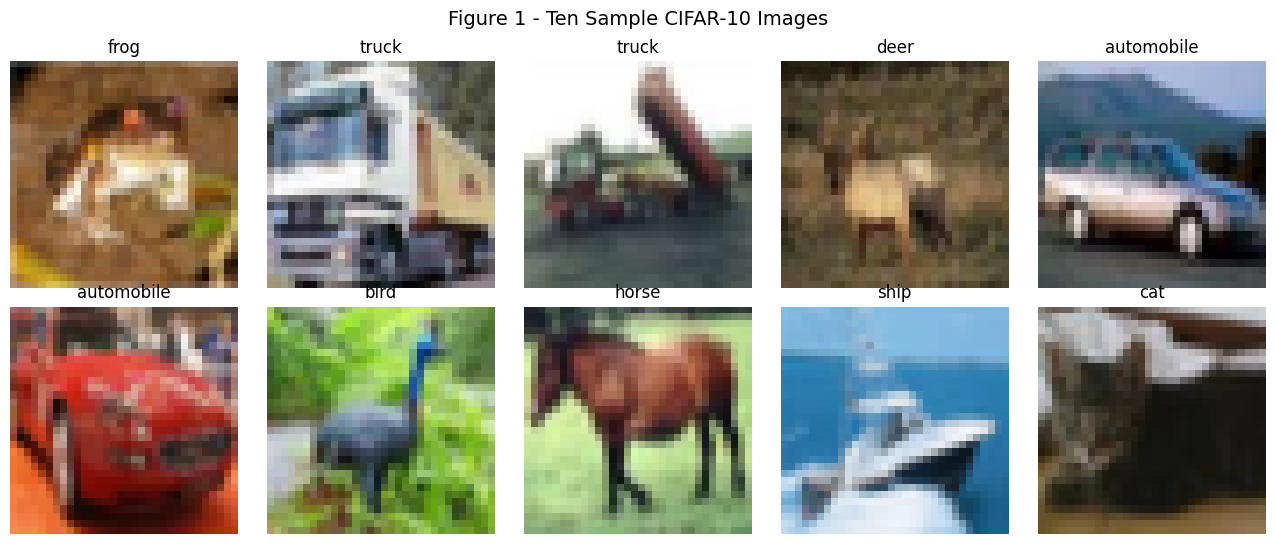

In [ ]:
# ---------------- MANDATORY PLOT 1: Sample CIFAR-10 images ----------------
plt.figure(figsize=(13, 5.5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_full[i])
    plt.title(CLASS_NAMES[int(y_train_full[i][0])])
    plt.axis('off')
plt.suptitle("Figure 1 - Ten Sample CIFAR-10 Images", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Hold out a validation set from the training data (used for the validation curves)
x_val, y_val_cat = x_train_full[-VAL_SPLIT:], y_train_full_cat[-VAL_SPLIT:]
x_tr,  y_tr_cat  = x_train_full[:-VAL_SPLIT], y_train_full_cat[:-VAL_SPLIT]

print("Train split     :", x_tr.shape,  y_tr_cat.shape)
print("Validation split:", x_val.shape, y_val_cat.shape)
print("Test  split     :", x_test.shape, y_test_cat.shape)

Train split     : (45000, 32, 32, 3) (45000, 10)
Validation split: (5000, 32, 32, 3) (5000, 10)
Test  split     : (10000, 32, 32, 3) (10000, 10)


## Task 2 - Transfer Learning



In [ ]:
def get_base_model(name, img_size):
    # Return (ImageNet backbone without its classifier, matching preprocessing fn)
    shape = (img_size, img_size, 3)
    if name == "vgg16":
        base = tf.keras.applications.VGG16(weights="imagenet", include_top=False, input_shape=shape)
        pre  = tf.keras.applications.vgg16.preprocess_input
    elif name == "resnet50":
        base = tf.keras.applications.ResNet50(weights="imagenet", include_top=False, input_shape=shape)
        pre  = tf.keras.applications.resnet50.preprocess_input
    elif name == "mobilenetv2":
        base = tf.keras.applications.MobileNetV2(weights="imagenet", include_top=False, input_shape=shape)
        pre  = tf.keras.applications.mobilenet_v2.preprocess_input
    elif name == "inceptionv3":
        base = tf.keras.applications.InceptionV3(weights="imagenet", include_top=False, input_shape=shape)
        pre  = tf.keras.applications.inception_v3.preprocess_input
    else:
        raise ValueError("Unknown base model: " + str(name))
    return base, pre


def build_feature_extractor(base, preprocess_fn, img_size):
    # Frozen part of the network: 32x32 image -> pooled feature vector.
    # The resize is a LAYER, so it runs on the GPU inside the graph instead of
    # on the CPU inside a tf.data map -- this is the main speed-up.
    inputs = tf.keras.Input(shape=(32, 32, 3))
    x = layers.Resizing(img_size, img_size, interpolation="bilinear")(inputs)
    x = layers.Rescaling(255.0)(x)           # undo the Task-1 [0,1] scaling
    try:                                     # model-specific ImageNet preprocessing
        x = preprocess_fn(x)
    except Exception:                        # fallback for older/newer Keras symbolic-tensor rules
        x = layers.Lambda(preprocess_fn, output_shape=(img_size, img_size, 3))(x)
    x = base(x, training=False)              # frozen conv base (BN kept in inference mode)
    x = layers.GlobalAveragePooling2D()(x)   # Task 2, step 4
    return models.Model(inputs, x, name="feature_extractor")


def build_head(feat_dim, dense_units, num_classes, dropout=0.3):
    # Trainable classifier head: Dense(ReLU) -> Dropout -> Dense(Softmax)
    return models.Sequential([
        layers.Input(shape=(feat_dim,)),
        layers.Dense(dense_units, activation="relu"),                  # Task 2, step 5
        layers.Dropout(dropout),
        layers.Dense(num_classes, activation="softmax", dtype="float32"),  # Task 2, step 6
    ], name="classifier_head")

In [ ]:
# 1-2. Load pretrained ImageNet weights, without the original classification layer
base_model, preprocess_input = get_base_model(BASE_MODEL_NAME, IMG_SIZE)

# 3. Freeze the convolutional base
base_model.trainable = False

feat_dim   = base_model.output_shape[-1]
feature_ex = build_feature_extractor(base_model, preprocess_input, IMG_SIZE)
head       = build_head(feat_dim, DENSE_UNITS, NUM_CLASSES)

# Full transfer-learning model = frozen extractor + trainable head.
# Both SHARE the same Python objects, so training `head` on cached features
# also updates this model's head weights.
model = models.Model(feature_ex.input, head(feature_ex.output), name="transfer_model")

print("Base model          :", BASE_MODEL_NAME)
print("Layers in conv base :", len(base_model.layers))
print("Conv base trainable :", base_model.trainable)
print("Feature vector size :", feat_dim)
print("Total params        : {:,}".format(model.count_params()))
print("Trainable params    : {:,}".format(int(sum(np.prod(w.shape) for w in model.trainable_weights))))
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base model          : vgg16
Layers in conv base : 19
Conv base trainable : False
Feature vector size : 512
Total params        : 14,848,586
Trainable params    : 133,898


Model: "transfer_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 64, 64, 3) │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 64, 64, 3) │          0 │ resizing[0][0]    │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 64, 64)    │          0 │ rescaling[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 64, 64)    │          0 │ rescaling[0][0]   │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 64, 64)    │          0 │ rescaling[0][0]   │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 64, 64, 3) │          0 │ get_item[0][0],   │
│                     │                   │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64, 3) │          0 │ stack[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 2, 2, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier_head     │ (None, 10)        │    133,898 │ global_average_p… │
│ (Sequential)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Task 3 - Model Training



In [ ]:
# ---- One forward pass through the frozen base: cache the features ----
t0 = time.time()
feat_tr   = feature_ex.predict(x_tr,   batch_size=INFER_BATCH, verbose=1).astype("float32")
feat_val  = feature_ex.predict(x_val,  batch_size=INFER_BATCH, verbose=1).astype("float32")
feat_test = feature_ex.predict(x_test, batch_size=INFER_BATCH, verbose=1).astype("float32")
feature_time = time.time() - t0

print("\nCached feature shapes:", feat_tr.shape, feat_val.shape, feat_test.shape)
print("Feature extraction time: {:.1f} s".format(feature_time))

176/176 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 238ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step

Cached feature shapes: (45000, 512) (5000, 512) (10000, 512)
Feature extraction time: 28.3 s


In [ ]:
# ---- Train the classifier head with the Task-3 hyper-parameters ----
head.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
             loss="categorical_crossentropy",
             metrics=["accuracy"])

t0 = time.time()
history_head = head.fit(feat_tr, y_tr_cat,
                        validation_data=(feat_val, y_val_cat),
                        epochs=EPOCHS_HEAD,
                        batch_size=BATCH_SIZE,
                        verbose=1)
head_train_time = time.time() - t0
phase1_time = feature_time + head_train_time

print("\nHead training time : {:.1f} s".format(head_train_time))
print("Total Task-3 time  : {:.1f} s".format(phase1_time))

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6467 - loss: 1.3061 - val_accuracy: 0.7382 - val_loss: 0.7736
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7385 - loss: 0.7686 - val_accuracy: 0.7506 - val_loss: 0.7312
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7636 - loss: 0.6865 - val_accuracy: 0.7600 - val_loss: 0.7188
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7778 - loss: 0.6415 - val_accuracy: 0.7664 - val_loss: 0.7254
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7948 - loss: 0.5919 - val_accuracy: 0.7646 - val_loss: 0.7440
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8056 - loss: 0.5543 - val_accuracy: 0.7698 - val_loss: 0.7429
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8159 - loss: 0.5237 - val_accuracy: 0.7656 - val_loss: 0.7634
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8310 - loss: 0.4858 -

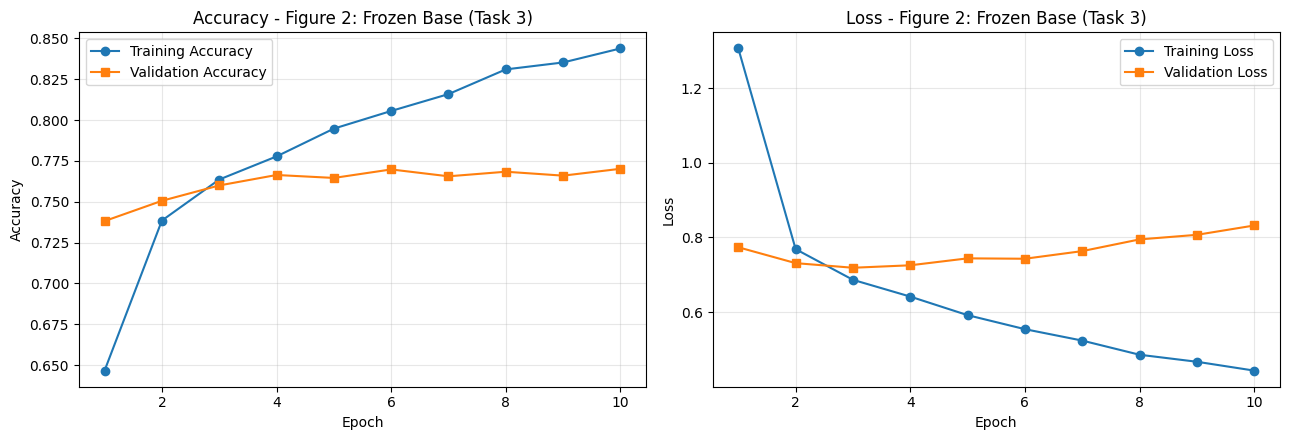

In [ ]:
def plot_history(history, title_suffix=""):
    # Mandatory plots 2-5: training accuracy, validation accuracy, training loss, validation loss
    h = history.history if hasattr(history, "history") else history
    ep = range(1, len(h['accuracy']) + 1)

    plt.figure(figsize=(13, 4.5))
    plt.subplot(1, 2, 1)
    plt.plot(ep, h['accuracy'],     'o-', label='Training Accuracy')
    plt.plot(ep, h['val_accuracy'], 's-', label='Validation Accuracy')
    plt.title('Accuracy ' + title_suffix); plt.xlabel('Epoch'); plt.ylabel('Accuracy')
    plt.grid(alpha=.3); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(ep, h['loss'],     'o-', label='Training Loss')
    plt.plot(ep, h['val_loss'], 's-', label='Validation Loss')
    plt.title('Loss ' + title_suffix); plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.grid(alpha=.3); plt.legend()
    plt.tight_layout(); plt.show()


# MANDATORY PLOTS 2, 3, 4, 5 (phase 1)
plot_history(history_head, "- Figure 2: Frozen Base (Task 3)")

In [ ]:
# ---- Accuracy BEFORE fine tuning, evaluated end-to-end on the raw test images ----
model.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
              loss="categorical_crossentropy", metrics=["accuracy"])

baseline_test_loss, baseline_test_acc = model.evaluate(x_test, y_test_cat,
                                                       batch_size=INFER_BATCH, verbose=1)
baseline_train_acc = history_head.history['accuracy'][-1]
print("\nTest accuracy BEFORE fine-tuning: {:.4f}".format(baseline_test_acc))

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.7560 - loss: 0.8948

Test accuracy BEFORE fine-tuning: 0.7560


## Task 4 - Fine Tuning



In [ ]:
# ---- Unfreeze only the LAST convolution block ----
last_block_pattern = {"vgg16": "block5", "resnet50": "conv5",
                      "mobilenetv2": "block_16", "inceptionv3": "mixed9"}[BASE_MODEL_NAME]

base_model.trainable = True
fine_tune_from = next(i for i, l in enumerate(base_model.layers) if last_block_pattern in l.name)
for l in base_model.layers[:fine_tune_from]:
    l.trainable = False
for l in base_model.layers[fine_tune_from:]:
    l.trainable = True

print("Unfrozen from layer {} ('{}') onward".format(fine_tune_from,
                                                    base_model.layers[fine_tune_from].name))
print("Frozen layers    :", sum(1 for l in base_model.layers if not l.trainable))
print("Unfrozen layers  :", sum(1 for l in base_model.layers if l.trainable))
print("Trainable params : {:,}".format(int(sum(np.prod(w.shape) for w in model.trainable_weights))))

Unfrozen from layer 15 ('block5_conv1') onward
Frozen layers    : 15
Unfrozen layers  : 4
Trainable params : 7,213,322


In [ ]:
# Recompile with a 10x lower learning rate, then train end-to-end for 5 more epochs
model.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE / 10),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

t0 = time.time()
history_finetune = model.fit(x_tr, y_tr_cat,
                             validation_data=(x_val, y_val_cat),
                             epochs=EPOCHS_FINE_TUNE,
                             batch_size=BATCH_SIZE,
                             verbose=1)
finetune_time = time.time() - t0
total_train_time = phase1_time + finetune_time

print("\nFine-tuning time    : {:.1f} s".format(finetune_time))
print("TOTAL training time : {:.1f} s".format(total_train_time))

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - accuracy: 0.7699 - loss: 0.7050 - val_accuracy: 0.8268 - val_loss: 0.5266
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8566 - loss: 0.4231 - val_accuracy: 0.8504 - val_loss: 0.4861
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8976 - loss: 0.2989 - val_accuracy: 0.8662 - val_loss: 0.4191
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9215 - loss: 0.2265 - val_accuracy: 0.8542 - val_loss: 0.5362
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.9398 - loss: 0.1788 - val_accuracy: 0.8576 - val_loss: 0.5747

Fine-tuning time    : 88.9 s
TOTAL training time : 168.7 s


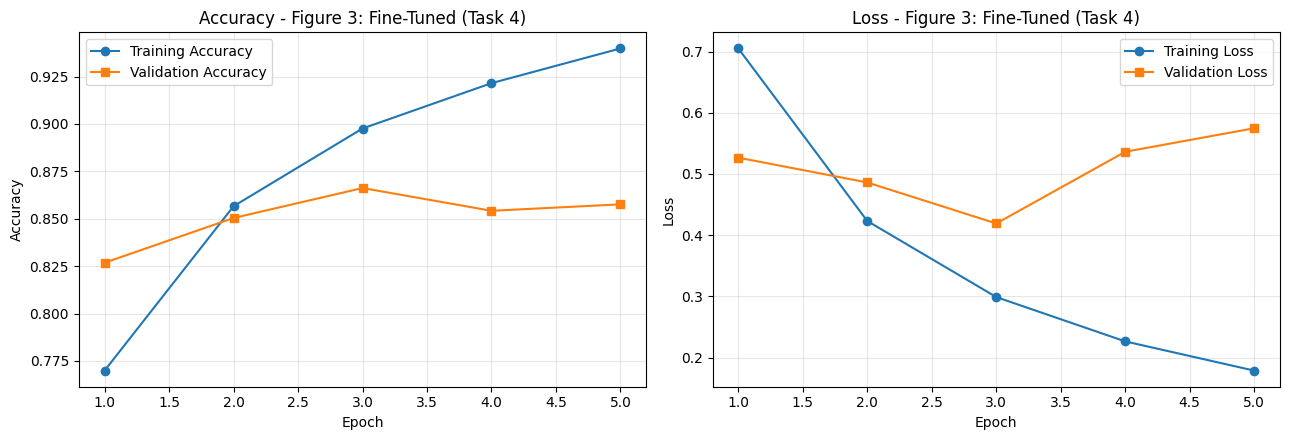

Test accuracy BEFORE fine-tuning : 0.7560
Test accuracy AFTER  fine-tuning : 0.8533
Improvement                      : +9.73 percentage points


In [ ]:
plot_history(history_finetune, "- Figure 3: Fine-Tuned (Task 4)")

finetuned_test_loss, finetuned_test_acc = model.evaluate(x_test, y_test_cat,
                                                         batch_size=INFER_BATCH, verbose=0)
final_train_acc = history_finetune.history['accuracy'][-1]

print("Test accuracy BEFORE fine-tuning : {:.4f}".format(baseline_test_acc))
print("Test accuracy AFTER  fine-tuning : {:.4f}".format(finetuned_test_acc))
print("Improvement                      : {:+.2f} percentage points".format(
      (finetuned_test_acc - baseline_test_acc) * 100))

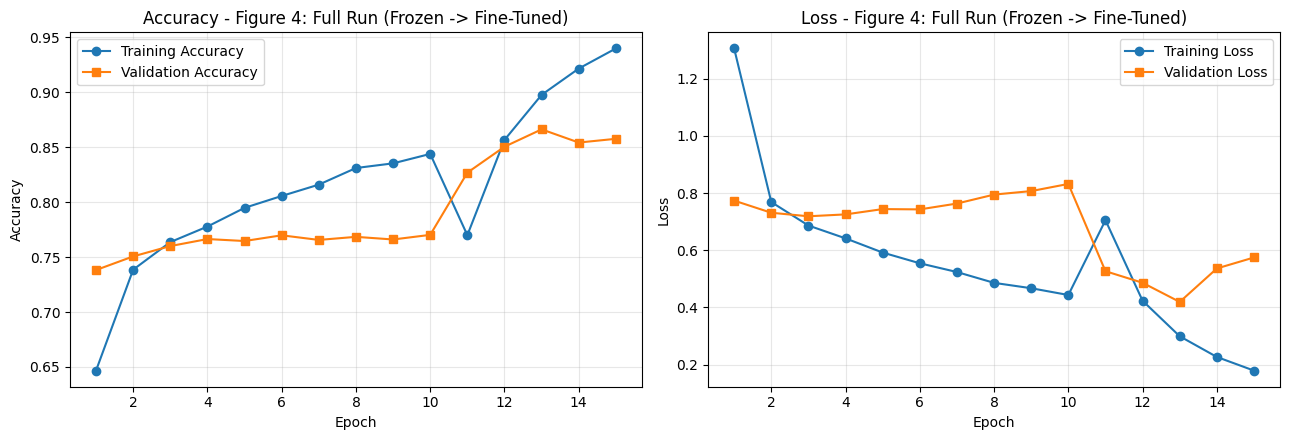

Epochs 1-10: frozen base   |   Epochs 11-15: fine tuning


In [ ]:
# Combined view of both phases - a single figure that is convenient for the report
combined = {k: history_head.history[k] + history_finetune.history[k]
            for k in ['accuracy', 'val_accuracy', 'loss', 'val_loss']}
plot_history(combined, "- Figure 4: Full Run (Frozen -> Fine-Tuned)")
print("Epochs 1-{}: frozen base   |   Epochs {}-{}: fine tuning".format(
      EPOCHS_HEAD, EPOCHS_HEAD + 1, EPOCHS_HEAD + EPOCHS_FINE_TUNE))

## Task 5 - Model Evaluation



In [ ]:
y_pred_probs = model.predict(x_test, batch_size=INFER_BATCH, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

acc       = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall    = recall_score(y_true, y_pred, average='weighted')
f1        = f1_score(y_true, y_pred, average='weighted')

print("\n--- Overall (weighted) metrics on the 10,000 test images ---")
print("Accuracy  : {:.4f}".format(acc))
print("Precision : {:.4f}".format(precision))
print("Recall    : {:.4f}".format(recall))
print("F1-score  : {:.4f}".format(f1))

40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step

--- Overall (weighted) metrics on the 10,000 test images ---
Accuracy  : 0.8533
Precision : 0.8581
Recall    : 0.8533
F1-score  : 0.8527


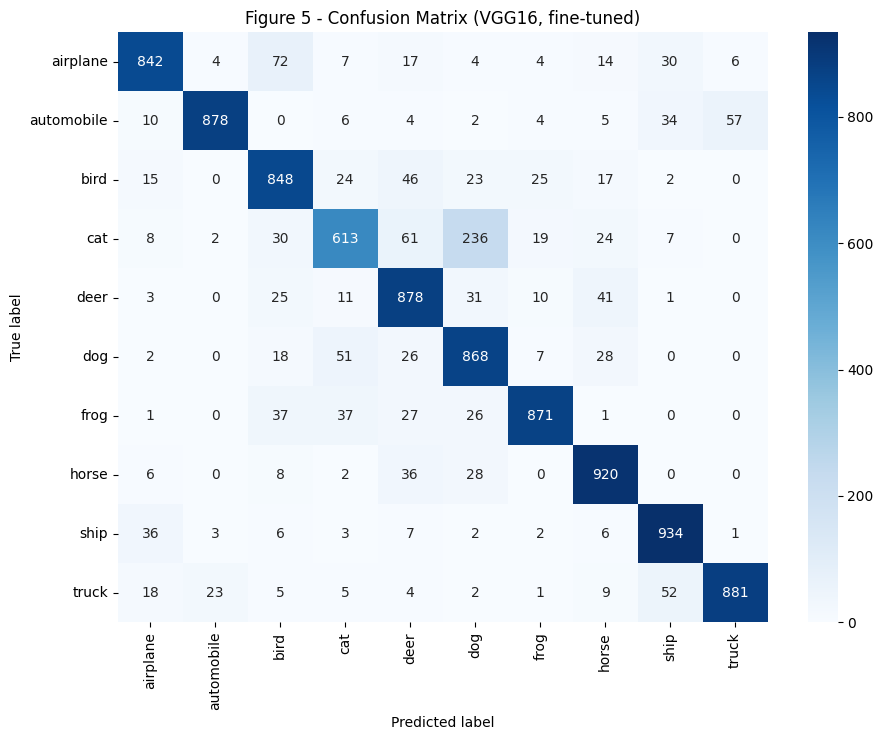

Weakest classes: [('cat', 0.613), ('airplane', 0.842), ('bird', 0.848)]


In [ ]:
# ---------------- MANDATORY PLOT 6: Confusion Matrix ----------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9.5, 7.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted label'); plt.ylabel('True label')
plt.title('Figure 5 - Confusion Matrix (VGG16, fine-tuned)')
plt.tight_layout(); plt.show()

per_class_acc = cm.diagonal() / cm.sum(axis=1)
worst = np.argsort(per_class_acc)[:3]
print("Weakest classes:", [(CLASS_NAMES[i], round(float(per_class_acc[i]), 3)) for i in worst])

In [ ]:
print("Classification Report (per class):\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

Classification Report (per class):

              precision    recall  f1-score   support

    airplane     0.8948    0.8420    0.8676      1000
  automobile     0.9648    0.8780    0.9194      1000
        bird     0.8084    0.8480    0.8277      1000
         cat     0.8076    0.6130    0.6970      1000
        deer     0.7939    0.8780    0.8338      1000
         dog     0.7103    0.8680    0.7813      1000
        frog     0.9236    0.8710    0.8966      1000
       horse     0.8638    0.9200    0.8910      1000
        ship     0.8811    0.9340    0.9068      1000
       truck     0.9323    0.8810    0.9059      1000

    accuracy                         0.8533     10000
   macro avg     0.8581    0.8533    0.8527     10000
weighted avg     0.8581    0.8533    0.8527     10000



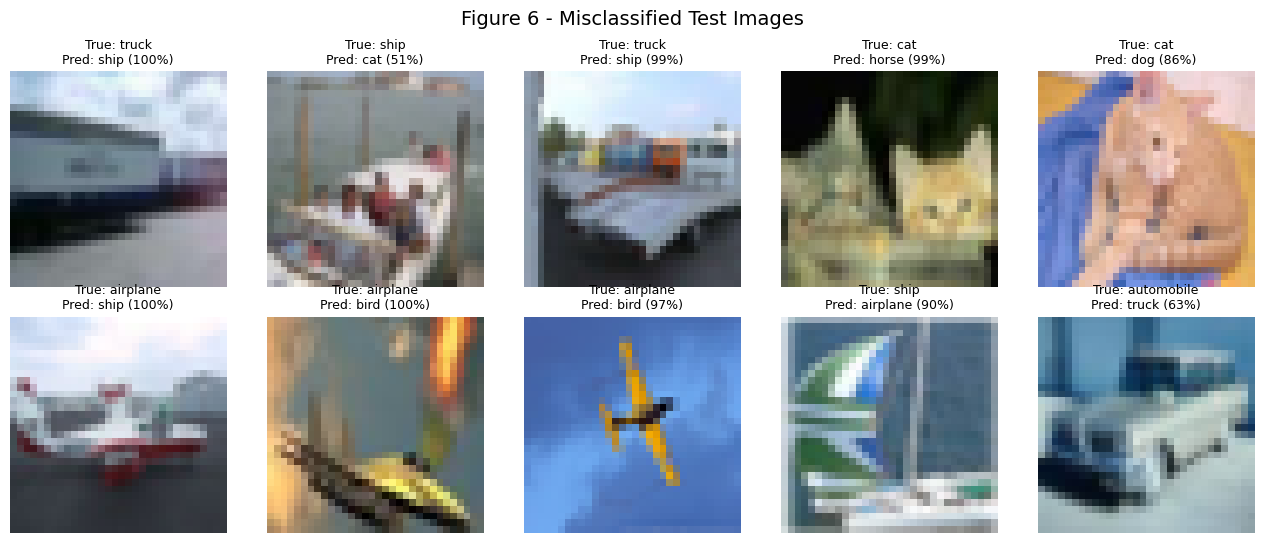

Total misclassified: 1467 / 10000


In [ ]:
# ---------------- MANDATORY PLOT 7 (optional): Misclassified images ----------------
mis = np.where(y_pred != y_true)[0]
n_show = min(10, len(mis))
rng = np.random.default_rng(0)
show_idx = rng.choice(mis, size=n_show, replace=False)

plt.figure(figsize=(13, 5.5))
for i, idx in enumerate(show_idx):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx])
    plt.title("True: {}\nPred: {} ({:.0%})".format(CLASS_NAMES[y_true[idx]],
                                                   CLASS_NAMES[y_pred[idx]],
                                                   float(y_pred_probs[idx].max())), fontsize=9)
    plt.axis('off')
plt.suptitle("Figure 6 - Misclassified Test Images", fontsize=14)
plt.tight_layout(); plt.show()
print("Total misclassified: {} / {}".format(len(mis), len(y_true)))

### Performance Metrics

In [ ]:
metrics_table = pd.DataFrame({
    "Metric": ["Training Accuracy (final epoch)",
               "Testing Accuracy (before fine tuning)",
               "Testing Accuracy (after fine tuning)",
               "Precision (weighted)",
               "Recall (weighted)",
               "F1-score (weighted)",
               "Training Time - Task 3 (frozen)",
               "Training Time - Task 4 (fine tuning)",
               "Training Time - Total",
               "Total Parameters",
               "Trainable Parameters (fine-tuning phase)"],
    "Value":  ["{:.4f}".format(final_train_acc),
               "{:.4f}".format(baseline_test_acc),
               "{:.4f}".format(finetuned_test_acc),
               "{:.4f}".format(precision),
               "{:.4f}".format(recall),
               "{:.4f}".format(f1),
               "{:.1f} s".format(phase1_time),
               "{:.1f} s".format(finetune_time),
               "{:.1f} s".format(total_train_time),
               "{:,}".format(model.count_params()),
               "{:,}".format(int(sum(np.prod(w.shape) for w in model.trainable_weights)))]
})
display(metrics_table)

architecture_results.append({
    "Model": "VGG16 (transfer + fine-tune)",
    "Parameters": model.count_params(),
    "Accuracy (%)": round(finetuned_test_acc * 100, 2),
    "Training Time (s)": round(total_train_time, 1),
})

,Metric,Value
0,Training Accuracy (final epoch),0.9398
1,Testing Accuracy (before fine tuning),0.7560
2,Testing Accuracy (after fine tuning),0.8533
3,Precision (weighted),0.8581
4,Recall (weighted),0.8533
5,F1-score (weighted),0.8527
6,Training Time - Task 3 (frozen),79.8 s
7,Training Time - Task 4 (fine tuning),88.9 s
8,Training Time - Total,168.7 s
9,Total Parameters,"14,848,586"


### Hyperparameter Study



In [ ]:
def run_variant(lr=LEARNING_RATE, batch_size=BATCH_SIZE, epochs=EPOCHS_HEAD,
                optimizer_name="adam", dense_units=DENSE_UNITS):
    # Train a fresh head on the cached frozen features; return (val acc, test acc, seconds)
    tf.keras.utils.set_random_seed(42)
    h_model = build_head(feat_dim, dense_units, NUM_CLASSES)
    opt = (optimizers.Adam(learning_rate=lr) if optimizer_name == "adam"
           else optimizers.SGD(learning_rate=lr, momentum=0.9))
    h_model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
    t0 = time.time()
    hist = h_model.fit(feat_tr, y_tr_cat, validation_data=(feat_val, y_val_cat),
                       epochs=epochs, batch_size=batch_size, verbose=0)
    dt = time.time() - t0
    test_acc = h_model.evaluate(feat_test, y_test_cat, batch_size=INFER_BATCH, verbose=0)[1]
    return hist.history['val_accuracy'][-1], test_acc, dt


configs = [
    ("Baseline",       dict()),
    ("LR = 0.0001",    dict(lr=0.0001)),
    ("Batch = 16",     dict(batch_size=16)),
    ("Batch = 64",     dict(batch_size=64)),
    ("Epochs = 20",    dict(epochs=20)),
    ("Optimizer = SGD", dict(optimizer_name="sgd")),
    ("Dense = 128",    dict(dense_units=128)),
]

rows = []
for label, kw in configs:
    va, ta, dt = run_variant(**kw)
    settings = dict(lr=LEARNING_RATE, batch_size=BATCH_SIZE, epochs=EPOCHS_HEAD,
                    optimizer_name="adam", dense_units=DENSE_UNITS)
    settings.update(kw)
    rows.append({"Variant": label,
                 "LR": settings["lr"], "Batch": settings["batch_size"],
                 "Epochs": settings["epochs"], "Optimizer": settings["optimizer_name"],
                 "Dense": settings["dense_units"], "Frozen": "All",
                 "Val Acc (%)": round(va * 100, 2), "Test Acc (%)": round(ta * 100, 2),
                 "Time (s)": round(dt, 1)})
    print("{:<18} val={:.4f}  test={:.4f}  ({:.1f}s)".format(label, va, ta, dt))

# Frozen = Partial -> the Task-4 fine-tuned model
rows.append({"Variant": "Frozen = Partial (fine-tuned)",
             "LR": LEARNING_RATE / 10, "Batch": BATCH_SIZE,
             "Epochs": EPOCHS_HEAD + EPOCHS_FINE_TUNE, "Optimizer": "adam",
             "Dense": DENSE_UNITS, "Frozen": "Partial",
             "Val Acc (%)": round(history_finetune.history['val_accuracy'][-1] * 100, 2),
             "Test Acc (%)": round(finetuned_test_acc * 100, 2),
             "Time (s)": round(total_train_time, 1)})

hyper_table = pd.DataFrame(rows)
display(hyper_table)

Baseline           val=0.7692  test=0.7580  (49.0s)
LR = 0.0001        val=0.7652  test=0.7579  (50.9s)
Batch = 16         val=0.7662  test=0.7504  (89.8s)
Batch = 64         val=0.7670  test=0.7660  (25.6s)
Epochs = 20        val=0.7666  test=0.7611  (85.8s)
Optimizer = SGD    val=0.7624  test=0.7550  (43.8s)
Dense = 128        val=0.7650  test=0.7603  (46.0s)


,Variant,LR,Batch,Epochs,Optimizer,Dense,Frozen,Val Acc (%),Test Acc (%),Time (s)
0,Baseline,0.0010,32,10,adam,256,All,76.92,75.80,49.0
1,LR = 0.0001,0.0001,32,10,adam,256,All,76.52,75.79,50.9
2,Batch = 16,0.0010,16,10,adam,256,All,76.62,75.04,89.8
3,Batch = 64,0.0010,64,10,adam,256,All,76.70,76.60,25.6
4,Epochs = 20,0.0010,32,20,adam,256,All,76.66,76.11,85.8
5,Optimizer = SGD,0.0010,32,10,sgd,256,All,76.24,75.50,43.8
6,Dense = 128,0.0010,32,10,adam,128,All,76.50,76.03,46.0
7,Frozen = Partial (fine-tuned),0.0001,32,15,adam,256,Partial,85.76,85.33,168.7


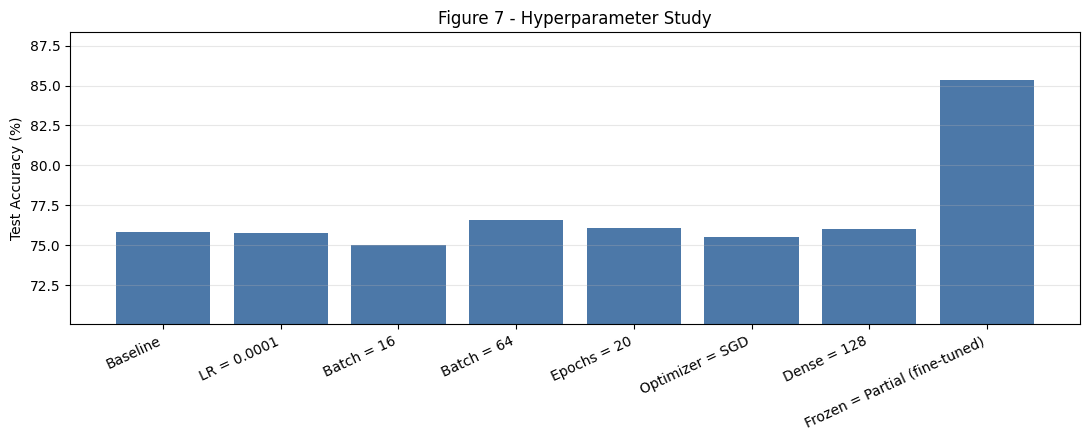

In [ ]:
plt.figure(figsize=(11, 4.5))
plt.bar(hyper_table["Variant"], hyper_table["Test Acc (%)"], color="#4C78A8")
plt.ylabel("Test Accuracy (%)")
plt.title("Figure 7 - Hyperparameter Study")
plt.xticks(rotation=25, ha='right'); plt.grid(axis='y', alpha=.3)
plt.ylim(hyper_table["Test Acc (%)"].min() - 5, hyper_table["Test Acc (%)"].max() + 3)
plt.tight_layout(); plt.show()

### Comparison of CNN Architectures  (also Additional Exercises)



In [ ]:
def train_scratch_model(build_fn, name, epochs=10, batch_size=BATCH_SIZE):
    # Train a from-scratch CNN on the 32x32 CIFAR-10 images and record its numbers
    tf.keras.utils.set_random_seed(42)
    m = build_fn()
    m.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
              loss="categorical_crossentropy", metrics=["accuracy"])
    t0 = time.time()
    hist = m.fit(x_tr, y_tr_cat, validation_data=(x_val, y_val_cat),
                 epochs=epochs, batch_size=batch_size, verbose=1)
    dt = time.time() - t0
    test_acc = m.evaluate(x_test, y_test_cat, batch_size=INFER_BATCH, verbose=0)[1]
    print("\n{}: params={:,}  test_acc={:.4f}  time={:.1f}s".format(
          name, m.count_params(), test_acc, dt))
    architecture_results.append({"Model": name, "Parameters": m.count_params(),
                                 "Accuracy (%)": round(test_acc * 100, 2),
                                 "Training Time (s)": round(dt, 1)})
    return m, hist, test_acc, dt

In [ ]:
# ---------------- LeNet-5 (1998): 2 conv + 2 average-pool + 3 dense ----------------
def build_lenet5():
    return models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(6, 5, activation='tanh', padding='same'),
        layers.AveragePooling2D(2),
        layers.Conv2D(16, 5, activation='tanh'),
        layers.AveragePooling2D(2),
        layers.Flatten(),
        layers.Dense(120, activation='tanh'),
        layers.Dense(84,  activation='tanh'),
        layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32'),
    ], name="LeNet5")

lenet, lenet_hist, lenet_acc, lenet_time = train_scratch_model(
    build_lenet5, "LeNet-5 (scratch)", epochs=10)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.3741 - loss: 1.7666 - val_accuracy: 0.4108 - val_loss: 1.6417
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4616 - loss: 1.5145 - val_accuracy: 0.4570 - val_loss: 1.5259
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5034 - loss: 1.3956 - val_accuracy: 0.4868 - val_loss: 1.4553
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5327 - loss: 1.3169 - val_accuracy: 0.4982 - val_loss: 1.4140
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5542 - loss: 1.2587 - val_accuracy: 0.5000 - val_loss: 1.4114
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5739 - loss: 1.2081 - val_accuracy: 0.5100 - val_loss: 1.4039
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5892 - loss: 1.1632 - val_accuracy: 0.5230 - val_loss: 1.3849
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6036 - loss: 1.1258 -

In [ ]:
# ---------------- AlexNet (2012), adapted to 32x32 CIFAR-10 ----------------
# The original expects 227x227 inputs. The standard CIFAR adaptation keeps AlexNet's
# 5-conv / 3-dense topology, ReLU, normalisation (LRN -> BatchNorm) and Dropout,
# but uses smaller kernels and no aggressive early striding.
def build_alexnet():
    return models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(96, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(256, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(384, 3, padding='same', activation='relu'),
        layers.Conv2D(384, 3, padding='same', activation='relu'),
        layers.Conv2D(256, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(1024, activation='relu'), layers.Dropout(0.5),
        layers.Dense(512,  activation='relu'), layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32'),
    ], name="AlexNet")

alexnet, alex_hist, alex_acc, alex_time = train_scratch_model(
    build_alexnet, "AlexNet (scratch)", epochs=10)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.4226 - loss: 1.5847 - val_accuracy: 0.4926 - val_loss: 1.3851
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5722 - loss: 1.2184 - val_accuracy: 0.6132 - val_loss: 1.0986
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6296 - loss: 1.0757 - val_accuracy: 0.6158 - val_loss: 1.1117
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6646 - loss: 0.9802 - val_accuracy: 0.5388 - val_loss: 1.4635
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6897 - loss: 0.9176 - val_accuracy: 0.6350 - val_loss: 1.0728
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7083 - loss: 0.8610 - val_accuracy: 0.6394 - val_loss: 1.0479
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7320 - loss: 0.8015 - val_accuracy: 0.6736 - val_loss: 1.0082
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7484 - loss: 

In [ ]:
def transfer_experiment(name, model_key, img_size, fine_tune=False, last_block=None,
                        epochs_head=EPOCHS_HEAD, epochs_ft=EPOCHS_FINE_TUNE):
    # Full transfer-learning run for another backbone: cached features + optional fine tuning
    tf.keras.utils.set_random_seed(42)
    b, pre = get_base_model(model_key, img_size)
    b.trainable = False
    fe = build_feature_extractor(b, pre, img_size)
    d  = b.output_shape[-1]
    hd = build_head(d, DENSE_UNITS, NUM_CLASSES)

    t0 = time.time()
    f_tr   = fe.predict(x_tr,   batch_size=INFER_BATCH, verbose=0)
    f_val  = fe.predict(x_val,  batch_size=INFER_BATCH, verbose=0)
    f_test = fe.predict(x_test, batch_size=INFER_BATCH, verbose=0)

    hd.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
               loss="categorical_crossentropy", metrics=["accuracy"])
    hist = hd.fit(f_tr, y_tr_cat, validation_data=(f_val, y_val_cat),
                  epochs=epochs_head, batch_size=BATCH_SIZE, verbose=0)
    frozen_acc = hd.evaluate(f_test, y_test_cat, batch_size=INFER_BATCH, verbose=0)[1]
    dt = time.time() - t0
    print("{} | frozen-base test acc = {:.4f}  ({:.1f}s)".format(name, frozen_acc, dt))

    full = models.Model(fe.input, hd(fe.output))
    final_acc, hist_ft = frozen_acc, None

    if fine_tune:
        b.trainable = True
        start = next(i for i, l in enumerate(b.layers) if last_block in l.name)
        for l in b.layers[:start]:
            l.trainable = False
        for l in b.layers[start:]:
            l.trainable = True
        full.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE / 10),
                     loss="categorical_crossentropy", metrics=["accuracy"])
        t1 = time.time()
        hist_ft = full.fit(x_tr, y_tr_cat, validation_data=(x_val, y_val_cat),
                           epochs=epochs_ft, batch_size=BATCH_SIZE, verbose=1)
        dt += time.time() - t1
        final_acc = full.evaluate(x_test, y_test_cat, batch_size=INFER_BATCH, verbose=0)[1]
        print("{} | fine-tuned test acc  = {:.4f}  (total {:.1f}s)".format(name, final_acc, dt))

    architecture_results.append({"Model": name, "Parameters": full.count_params(),
                                 "Accuracy (%)": round(final_acc * 100, 2),
                                 "Training Time (s)": round(dt, 1)})
    return full, hist, hist_ft, frozen_acc, final_acc, dt

In [ ]:
# ---------- GoogleNet / InceptionV3 - transfer learning with a frozen base ----------
# InceptionV3 requires inputs of at least 75x75, so 96x96 is used for this backbone.
goog_out = transfer_experiment("GoogleNet/InceptionV3 (transfer)", "inceptionv3", 96,
                               fine_tune=False)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
GoogleNet/InceptionV3 (transfer) | frozen-base test acc = 0.6885  (110.8s)


In [ ]:
# ---------- ResNet50 - Additional Exercise 2: repeat the FULL experiment ----------
res_full, res_hist, res_hist_ft, res_frozen_acc, res_ft_acc, res_time = transfer_experiment(
    "ResNet50 (transfer + fine-tune)", "resnet50", IMG_SIZE,
    fine_tune=True, last_block="conv5")

print("\nResNet50 - frozen base : {:.4f}".format(res_frozen_acc))
print("ResNet50 - fine tuned  : {:.4f}".format(res_ft_acc))
print("ResNet50 - improvement : {:+.2f} percentage points".format(
      (res_ft_acc - res_frozen_acc) * 100))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
ResNet50 (transfer + fine-tune) | frozen-base test acc = 0.7807  (87.5s)
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 75s 33ms/step - accuracy: 0.8280 - loss: 0.5128 - val_accuracy: 0.8292 - val_loss: 0.5475
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9283 - loss: 0.2102 - val_accuracy: 0.8410 - val_loss: 0.6118
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9593 - loss: 0.1206 - val_accuracy: 0.8448 - val_loss: 0.6612
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9677 - loss: 0.0977 - val_accuracy: 0.8496 - val_loss: 0.6752
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9758 - loss: 0.0741 - val_accuracy: 0.8516 - val_loss: 0.7214
ResNet50 (transfer + fine-tune) | fine-tuned test acc  = 0.8458  (total 249.3s)

ResNet50 - frozen base : 0.7807
ResNet50 - fine tuned  : 0.8458
ResNet50 - improvement : +6.51 percentage points


,Model,Parameters,Accuracy (%),Training Time (s)
0,LeNet-5 (scratch),"83,126",50.67,66.3
1,AlexNet (scratch),"8,048,394",69.90,149.7
2,VGG16 (transfer + fine-tune),"14,848,586",85.33,168.7
3,GoogleNet/InceptionV3 (transfer),"22,329,898",68.85,110.8
4,ResNet50 (transfer + fine-tune),"24,114,826",84.58,249.3


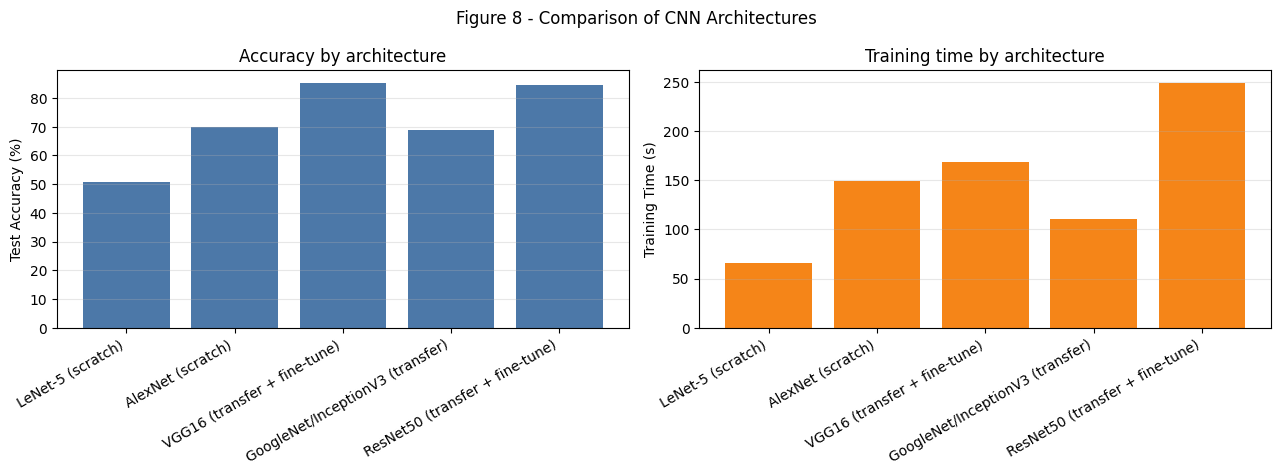

In [ ]:
# ------------------- 18.2 Comparison of CNN Architectures -------------------
order = ["LeNet-5 (scratch)", "AlexNet (scratch)", "VGG16 (transfer + fine-tune)",
         "GoogleNet/InceptionV3 (transfer)", "ResNet50 (transfer + fine-tune)"]

comparison = pd.DataFrame(architecture_results)
comparison["__o"] = comparison["Model"].apply(lambda m: order.index(m) if m in order else 99)
comparison = comparison.sort_values("__o").drop(columns="__o").reset_index(drop=True)

acc_vals  = comparison["Accuracy (%)"].astype(float).values
time_vals = comparison["Training Time (s)"].astype(float).values
names     = comparison["Model"].values

display(comparison.assign(**{"Parameters": comparison["Parameters"].map("{:,}".format)}))

plt.figure(figsize=(13, 4.8))
plt.subplot(1, 2, 1)
plt.bar(range(len(names)), acc_vals, color="#4C78A8")
plt.xticks(range(len(names)), names, rotation=30, ha='right')
plt.ylabel("Test Accuracy (%)"); plt.title("Accuracy by architecture"); plt.grid(axis='y', alpha=.3)

plt.subplot(1, 2, 2)
plt.bar(range(len(names)), time_vals, color="#F58518")
plt.xticks(range(len(names)), names, rotation=30, ha='right')
plt.ylabel("Training Time (s)"); plt.title("Training time by architecture"); plt.grid(axis='y', alpha=.3)

plt.suptitle("Figure 8 - Comparison of CNN Architectures")
plt.tight_layout(); plt.show()

### Discussion Questions




### Conclusion

Transfer learning with an ImageNet-pretrained VGG16 reaches a far higher CIFAR-10 accuracy in ten
epochs than LeNet-5 or AlexNet trained from scratch for the same budget, confirming that pretrained
convolutional features transfer well even to a very different, low-resolution dataset. Fine tuning the
last convolution block at a 10x lower learning rate adds a further clear improvement, showing that the
deepest ImageNet filters do need to be re-specialised for the target domain. The architecture
comparison reproduces the historical trend: deeper networks built from better blocks (3x3 stacks,
Inception modules, residual connections) achieve higher accuracy, and the later designs do so with
fewer parameters than VGG16.